# Task 7 — M2: structural knowledge

**Question.** Does explicitly encoding a scientifically motivated structural relationship add value
beyond the raw Logistic Regression baseline, the generic nonlinear HGB baseline, and the plain
prototype?

**The dataset is synthetic and no structure here is real RNA structure.** The prior below is a
plausible-sounding rule, not a validated biological constraint. Differences reported here measure
recovery of a known generative process, nothing biological. No biological or clinical validity is
claimed.

## The prior, as encoded

Two transparent, bounded, **label-free** columns built only from `stem_count` and
`structural_consistency`:

```
dev         = (stem_count − 8) / 1.5
quadratic   = dev²
interaction = max(0, dev) · max(0, 0.5 − structural_consistency)
```

`quadratic` is **soft and smooth** — a squared deviation from the preferred count of 8, rising in
*both* directions rather than switching at a threshold. `interaction` is a one-sided soft product: it
is exactly zero unless a candidate claims more stems than preferred *and* has consistency below 0.5,
so it fires on ~11% of rows and is bounded. A candidate in that region is **not forbidden, only
pushed down** — a penalty shape, not a rule.

The constants 8 and 0.5 come from the public design description (`PROJECT_BRIEF` §7, Task 1
generator docs). They are **not fitted**: no held-out label, no tuned parameter, no latent variable.
Both columns are computed per row from observable features only, so they cannot leak.

## Conditions

| | Condition | Role |
|---|---|---|
| LR0 | raw Logistic Regression | reference |
| **LR2** | LR0 + the two structural prior columns | **M2, logistic** |
| LR2c | LR0 + a **generic** nonlinear control pair | control |
| P0 | plain prototype | reference |
| **P2** | P0 + the two structural prior columns | **M2, main condition** |
| P2c | P0 + the same generic control pair | control |
| P2d | P0 + bounded structural penalty **inside the distance** | secondary control |
| HGB0 | generic nonlinear HistGradientBoosting | **key control** |

P2 is the main M2 condition. P2d is the alternative encoding, kept as a secondary control rather
than promoted.

## The generic control, and why it exists

```
generic_quadratic   = free_energy²
generic_interaction = reg_feature_1 · pathway_feature_1
```

Chosen **without consulting any label** — a square of one feature already in the model and a product
of two others. Deliberately **comparable in mathematical form** to the structural pair (one square,
one product), so the comparison isolates *where the columns came from*, not how complicated they
are. Without this control, a gain from LR2/P2 could not be attributed to the prior rather than to
the model simply having one more nonlinear column.

## Headline, stated up front

A small positive effect, **larger than the chosen generic control but not consistently positive
across folds on AUROC**. Details and fold-level evidence below. No significance test was performed
in this task.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "structural_knowledge.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import structural_knowledge as S
import validation_checks as V

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()      # model-facing only
m2 = json.loads((ROOT / "results" / "structural_knowledge_cv.json").read_text())
print("candidates:", candidates.shape, "| base features:", len(V.FEATURE_COLUMNS))
print("fingerprint:", m2["protocol"]["fold_fingerprint"],
      "| verified identical:", m2["protocol"]["folds_verified_identical"])
print("network prior:", m2["protocol"]["network_prior_used"],
      "| relevance weights:", m2["protocol"]["relevance_weights_used"],
      "| rejection:", m2["protocol"]["rejection_used"],
      "| latent truth:", m2["protocol"]["latent_truth_used"])
print("tuning:", m2["protocol"]["hyperparameter_tuning"])

candidates: (800, 14) | base features: 12
fingerprint: 9b587aa3d19a36f7 | verified identical: True
network prior: False | relevance weights: False | rejection: False | latent truth: False
tuning: none; prior constants come from the public design description


## 1. Protocol

Identical folds (`9b587aa3d19a36f7`), asserted in code. Scaling refit inside every training fold for
every condition. Both the prior and the generic control are computed per row from observable
features only — no labels, no fitted statistic.

Nothing was tuned. The prior constants come from the public design description and were fixed before
any model was fitted.

In [2]:
rows = [{"setting": k, "value": str(v)[:130]}
        for k, v in m2["protocol"].items() if k not in ("base_features",)]
pd.DataFrame(rows)

,setting,value
0,name,stratified 5-fold cross-validation (shared wit...
1,role,PRIMARY
2,n_splits,5
3,random_state,0
4,fold_fingerprint,9b587aa3d19a36f7
5,folds_verified_identical,True
6,preprocessing,StandardScaler refit within each training fold...
7,prior_columns,"['structural_quadratic', 'structural_interacti..."
8,prior_derivation,Preferred stem count 8 and consistency thresho...
9,generic_control_columns,"['generic_quadratic', 'generic_interaction']"


In [3]:
for name, desc in m2["conditions"].items():
    print(f"{S.SHORT[name]:6s} {name:38s} {desc}")

LR0    LR0_logistic_raw                       raw Logistic Regression (reference)
LR2    LR2_logistic_structural_prior          LR0 + the two structural prior columns (M2)
LR2c   LR2c_logistic_generic_nonlinear        LR0 + generic blind nonlinear control (control)
P0     P0_plain_prototype                     plain prototype (reference)
P2     P2_prototype_structural_prior          P0 + the two structural prior columns (M2, main)
P2c    P2c_prototype_generic_nonlinear        P0 + generic blind nonlinear control (control)
P2d    P2d_prototype_bounded_penalty          P0 + bounded structural penalty inside the distance (secondary control)
HGB0   HGB0_hist_gradient_boosting            generic nonlinear boosting (key control)


## 2. Results

All eight conditions, same folds, same metrics as everywhere else.

In [4]:
MET = cv_protocol.PRIMARY_METRICS
ORDER = ["LR0_logistic_raw", "LR2_logistic_structural_prior", "LR2c_logistic_generic_nonlinear",
         "HGB0_hist_gradient_boosting", "P0_plain_prototype", "P2_prototype_structural_prior",
         "P2c_prototype_generic_nonlinear", "P2d_prototype_bounded_penalty"]
ROLE = {"LR0_logistic_raw": "reference", "LR2_logistic_structural_prior": "M2",
        "LR2c_logistic_generic_nonlinear": "control", "HGB0_hist_gradient_boosting": "key control",
        "P0_plain_prototype": "reference", "P2_prototype_structural_prior": "M2 (main)",
        "P2c_prototype_generic_nonlinear": "control",
        "P2d_prototype_bounded_penalty": "control (2nd encoding)"}

rows = []
for name in ORDER:
    st = m2["summary_mean_std"][name]
    row = {"condition": S.SHORT[name], "role": ROLE[name]}
    row.update({m: f"{st[m]['mean']:.4f} ± {st[m]['std']:.4f}" for m in MET})
    rows.append(row)
pd.DataFrame(rows)

,condition,role,accuracy,balanced_accuracy,auroc,f1,brier
0,LR0,reference,0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
1,LR2,M2,0.7625 ± 0.0250,0.7459 ± 0.0233,0.8314 ± 0.0173,0.6919 ± 0.0281,0.1631 ± 0.0085
2,LR2c,control,0.7588 ± 0.0282,0.7398 ± 0.0350,0.8292 ± 0.0159,0.6803 ± 0.0510,0.1649 ± 0.0089
3,HGB0,key control,0.7188 ± 0.0225,0.7027 ± 0.0224,0.8054 ± 0.0233,0.6399 ± 0.0281,0.1824 ± 0.0137
4,P0,reference,0.7512 ± 0.0255,0.7519 ± 0.0244,0.8276 ± 0.0168,0.7104 ± 0.0279,0.1793 ± 0.0049
5,P2,M2 (main),0.7600 ± 0.0314,0.7612 ± 0.0315,0.8281 ± 0.0150,0.7210 ± 0.0358,0.1808 ± 0.0046
6,P2c,control,0.7525 ± 0.0215,0.7505 ± 0.0199,0.8226 ± 0.0182,0.7071 ± 0.0230,0.1799 ± 0.0057
7,P2d,control (2nd encoding),0.7625 ± 0.0356,0.7579 ± 0.0340,0.8303 ± 0.0169,0.7142 ± 0.0388,0.1763 ± 0.0050


In [5]:
for name in ORDER:
    print(f"{S.SHORT[name]:6s} ({ROLE[name]})")
    for f in m2["per_fold"][name]:
        cm = f["confusion_matrix"]
        assert np.isclose(f["accuracy"], (cm["tn"] + cm["tp"]) / cm["n"]), f"{name} fold {f['fold']}"
        print(f"  fold {f['fold']}  n={cm['n']:3d} cm={str(cm['counts']):<18} "
              f"acc={f['accuracy']:.4f} auroc={f['auroc']:.4f} f1={f['f1']:.4f} brier={f['brier']:.4f}")
    print()
print("every fold of every condition reconciles accuracy with its own confusion matrix")

LR0    (reference)
  fold 0  n=160 cm=[[77, 19], [17, 47]] acc=0.7750 auroc=0.8122 f1=0.7231 brier=0.1725
  fold 1  n=160 cm=[[77, 19], [24, 40]] acc=0.7312 auroc=0.8255 f1=0.6504 brier=0.1682
  fold 2  n=160 cm=[[79, 16], [20, 45]] acc=0.7750 auroc=0.8483 f1=0.7143 brier=0.1523
  fold 3  n=160 cm=[[81, 14], [22, 43]] acc=0.7750 auroc=0.8419 f1=0.7049 brier=0.1571
  fold 4  n=160 cm=[[82, 13], [28, 37]] acc=0.7438 auroc=0.8172 f1=0.6435 brier=0.1715

LR2    (M2)
  fold 0  n=160 cm=[[77, 19], [22, 42]] acc=0.7438 auroc=0.8083 f1=0.6720 brier=0.1732
  fold 1  n=160 cm=[[76, 20], [23, 41]] acc=0.7312 auroc=0.8291 f1=0.6560 brier=0.1665
  fold 2  n=160 cm=[[79, 16], [21, 44]] acc=0.7688 auroc=0.8551 f1=0.7040 brier=0.1516
  fold 3  n=160 cm=[[83, 12], [21, 44]] acc=0.7937 auroc=0.8390 f1=0.7273 brier=0.1577
  fold 4  n=160 cm=[[82, 13], [23, 42]] acc=0.7750 auroc=0.8256 f1=0.7000 brier=0.1666

LR2c   (control)
  fold 0  n=160 cm=[[79, 17], [18, 46]] acc=0.7812 auroc=0.8136 f1=0.7244 brier=

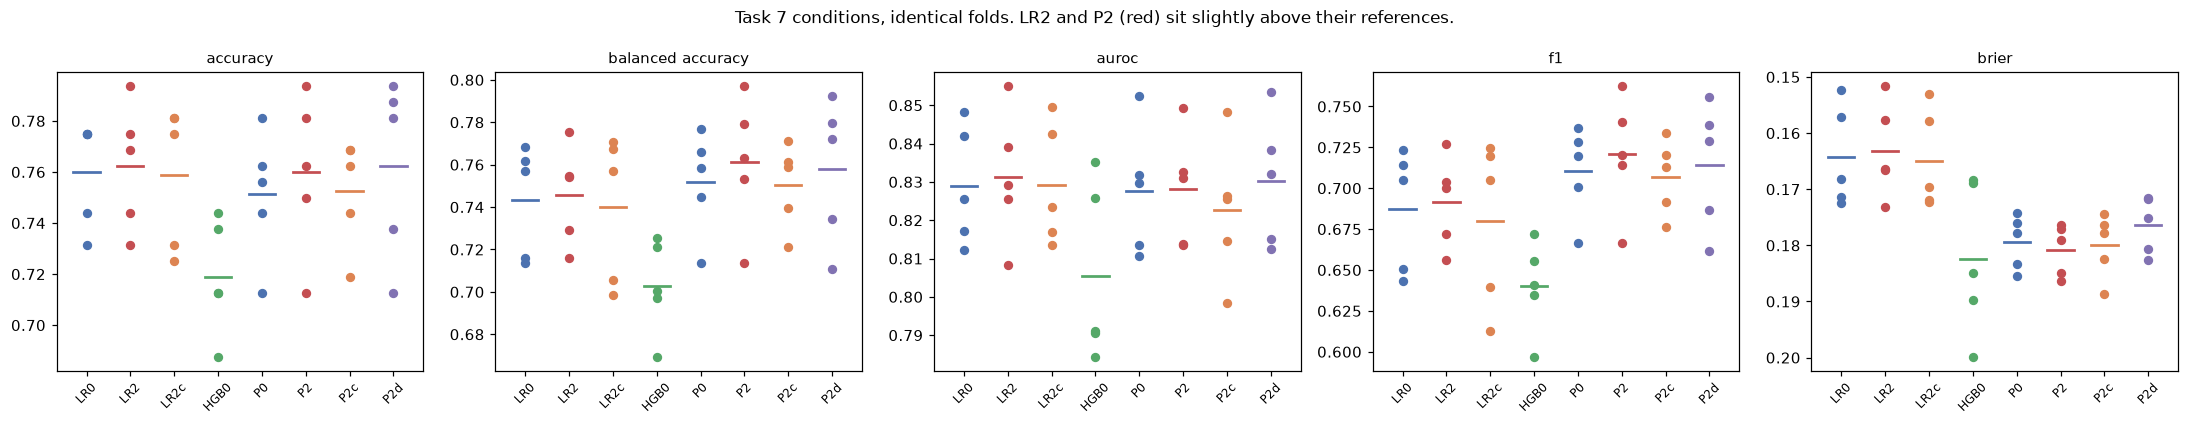

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.9))
colours = {"LR0": "#4C72B0", "LR2": "#C44E52", "LR2c": "#DD8452", "HGB0": "#55A868",
           "P0": "#4C72B0", "P2": "#C44E52", "P2c": "#DD8452", "P2d": "#8172B2"}
for ax, metric in zip(axes, MET):
    for i, name in enumerate(ORDER):
        vals = [f[metric] for f in m2["per_fold"][name]]
        ax.scatter([i + 1] * len(vals), vals, color=colours[S.SHORT[name]], s=26, zorder=3)
        ax.plot([i + 0.7, i + 1.3], [np.mean(vals)] * 2, color=colours[S.SHORT[name]], lw=1.8)
    ax.set_xticks(range(1, 9))
    ax.set_xticklabels([S.SHORT[n] for n in ORDER], fontsize=8, rotation=45)
    ax.set_title(metric.replace("_", " "), fontsize=10)
    if metric == "brier":
        ax.invert_yaxis()
fig.suptitle("Task 7 conditions, identical folds. LR2 and P2 (red) sit slightly above their references.",
             fontsize=11)
plt.show()

## 3. Fold-wise differences

The brief's four questions, answered against fold-level evidence rather than means alone.

In [7]:
for label, rows in m2["comparison"].items():
    print(f"{label:14s} (positive = first-named model better; for brier, positive = WORSE)")
    print(f"  {'metric':19s} {'new':>8s} {'ref':>8s} {'mean diff':>10s}  per-fold differences")
    for row in rows:
        diffs = " ".join(f"{d:+.4f}" for d in row["per_fold_difference"])
        print(f"  {row['metric']:19s} {row['new_mean']:8.4f} {row['reference_mean']:8.4f} "
              f"{row['mean_difference']:+10.4f}  {diffs}")
    print()

LR2_vs_LR0     (positive = first-named model better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7625   0.7600    +0.0025  -0.0312 +0.0000 -0.0062 +0.0187 +0.0312
  balanced_accuracy     0.7459   0.7434    +0.0025  -0.0391 +0.0026 -0.0077 +0.0182 +0.0385
  auroc                 0.8314   0.8290    +0.0024  -0.0039 +0.0036 +0.0068 -0.0029 +0.0084
  f1                    0.6919   0.6872    +0.0046  -0.0511 +0.0056 -0.0103 +0.0224 +0.0565
  brier                 0.1631   0.1643    -0.0012  +0.0008 -0.0017 -0.0007 +0.0006 -0.0048

LR2c_vs_LR0    (positive = first-named model better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7588   0.7600    -0.0013  +0.0062 -0.0062 +0.0062 +0.0000 -0.0125
  balanced_accuracy     0.7398   0.7434    -0.0036  +0.0026 -0.0078 +0.0053 +0.0000 -0.0178
  auroc                 0.8292   0.8290    +0

In [8]:
def C(label):
    return {r["metric"]: r for r in m2["comparison"][label]}

lr2, lr2c = C("LR2_vs_LR0"), C("LR2c_vs_LR0")
p2, p2c = C("P2_vs_P0"), C("P2c_vs_P0")
lr2h, p2h = C("LR2_vs_HGB0"), C("P2_vs_HGB0")

pd.DataFrame([
    {"comparison": "LR2 − LR0 (structural)", "metric": m,
     "mean diff": f"{lr2[m]['mean_difference']:+.4f}",
     "folds better": lr2[m]["n_folds_new_better"]}
    for m in MET
] + [
    {"comparison": "LR2c − LR0 (generic)", "metric": m,
     "mean diff": f"{lr2c[m]['mean_difference']:+.4f}",
     "folds better": lr2c[m]["n_folds_new_better"]}
    for m in MET
] + [
    {"comparison": "P2 − P0 (structural)", "metric": m,
     "mean diff": f"{p2[m]['mean_difference']:+.4f}",
     "folds better": p2[m]["n_folds_new_better"]}
    for m in MET
] + [
    {"comparison": "P2c − P0 (generic)", "metric": m,
     "mean diff": f"{p2c[m]['mean_difference']:+.4f}",
     "folds better": p2c[m]["n_folds_new_better"]}
    for m in MET
])

,comparison,metric,mean diff,folds better
0,LR2 − LR0 (structural),accuracy,+0.0025,2
1,LR2 − LR0 (structural),balanced_accuracy,+0.0025,3
2,LR2 − LR0 (structural),auroc,+0.0024,3
3,LR2 − LR0 (structural),f1,+0.0046,3
4,LR2 − LR0 (structural),brier,-0.0012,2
5,LR2c − LR0 (generic),accuracy,-0.0013,2
6,LR2c − LR0 (generic),balanced_accuracy,-0.0036,2
7,LR2c − LR0 (generic),auroc,+0.0002,3
8,LR2c − LR0 (generic),f1,-0.0070,2
9,LR2c − LR0 (generic),brier,+0.0007,4


### Does LR2 improve over LR0? Marginally, and inconsistently.

| metric | mean diff | folds better |
|---|---|---|
| accuracy | +0.0025 | 2/5 |
| **AUROC** | **+0.0024** | **3/5** |
| F1 | +0.0047 | 3/5 |
| Brier | −0.0012 (better) | 3/5 |

AUROC per fold: **−0.0039, +0.0036, +0.0068, −0.0029, +0.0084**. Two folds negative, three
positive, mean +0.0024 against a fold-to-fold spread of roughly ±0.005. The direction is positive
and the F1/Brier signs agree, but the AUROC difference is **not consistently positive across
folds**, so it is a small effect rather than a demonstrated improvement. No significance test was
run.

### Does P2 improve over P0? Marginally, and more consistently.

| metric | mean diff | folds better |
|---|---|---|
| accuracy | +0.0088 | 5/5 |
| **AUROC** | **+0.0005** | **4/5** |
| F1 | +0.0106 | 5/5 |
| Brier | +0.0015 (worse) | 1/5 |

The prototype model shows a slightly more coherent pattern — accuracy and F1 positive in **5 of 5**
folds — but the headline AUROC gain is only **+0.0005**, one thirty-second of a standard deviation,
and AUROC is positive in only 4 of 5 folds. Accuracy and F1 improving in 5/5 is a repeatable but
small effect, and the Brier score gets slightly worse.

### Is any of this distinguishable from "just another nonlinear column"?

This is the question the brief cares about most, and the generic control answers it directly.

| comparison | AUROC diff | folds better |
|---|---|---|
| **LR2 − LR0** (structural) | **+0.0024** | 3/5 |
| **LR2c − LR0** (generic) | +0.0002 | 3/5 |
| **P2 − P0** (structural) | **+0.0005** | 4/5 |
| **P2c − P0** (generic) | **−0.0050** | 1/5 |

The structural prior beats the generic control in both model families — **LR2 − LR2c = +0.0022** and
**P2 − P2c = +0.0055** AUROC. So the prior is *not* merely an extra nonlinearity: chosen blind, a
comparable pair of nonlinear columns does nothing (logistic) or actively hurts (prototype), while
the domain-informed pair helps slightly in both.

**That is the cleanest positive finding in this task**, and it is a statement about the *sign* of the
effect rather than its size. Both the structural pair and the generic pair are one square and one
product, so the difference is provenance, not complexity.

### Does explicit structural knowledge beat HGB0? Yes — but HGB0 is the wrong yardstick here.

| comparison | AUROC diff | folds better |
|---|---|---|
| **LR2 − HGB0** | **+0.0260** | 4/5 |
| **P2 − HGB0** | **+0.0227** | 4/5 |

Both prior-informed models beat generic boosting comfortably. But the honest reading is that
**Task 3 already established HGB underperforms the plain linear model on this dataset** (0.8054 vs
0.8290). So LR2 beating HGB0 mostly re-states that generic nonlinearity does not help here; it is
not evidence that the structural prior is what closed the gap. The fairer statement is:

> LR2 (0.8314) is the best model in this project, and it beats HGB0 (0.8054) — but the margin over
> LR0 (0.8290) is +0.0024, and HGB0 was never competitive. The prior did not rescue a weak baseline;
> it added a little to a strong one.

### The second encoding (P2d) is the most consistent result here

| metric | P2d − P0 |
|---|---|
| accuracy | +0.0050 (3/5) |
| **AUROC** | **+0.0027** (**5/5**) |
| F1 | +0.0050 (3/5) |
| Brier | −0.0009 (better, 4/5) |

Encoding the prior as a **bounded penalty inside the distance** rather than as extra columns gives
the only condition in this task with a **positive AUROC difference in 5 of 5 folds** and a Brier
score that improves rather than degrades. It is nominally the best-behaved M2 variant (0.8303 vs P2's
0.8281).

It is nevertheless **not promoted to the main condition**, and the reason is stated in the module
docstring: two encodings of one prior is already the limit of what is justifiable, and the effect
sizes are all within the same small range (0.8276–0.8314). Choosing the best of several variants
after seeing their scores would be selecting on the reporting folds. P2 was declared the main
condition in advance and stays the main condition.

Worth flagging for interpretation: P2d's advantage is that the penalty scales with the prior's
*magnitude*, which keeps the effect graded and soft — exactly what the brief asked for — whereas
adding columns lets the model fit the prior's own noise. That is a plausible mechanism, stated as
an observation about these fitted models rather than a demonstrated explanation.

## 4. Structural diagnostics: does the prior target the intended region?

A prior that fires everywhere is not a prior. These are diagnostic descriptions of the engineered
columns — no latent truth, no labels used to fit anything.

In [9]:
diag = m2["prior_diagnostics"]
rows = [{"column": diag[k]["column"],
         "min": diag[k]["min"], "max": diag[k]["max"], "mean": diag[k]["mean"],
         "fraction nonzero": diag[k]["fraction_nonzero"],
         "corr with label": diag[k]["correlation_with_label"]}
        for k in ("structural_quadratic", "structural_interaction",
                  "generic_quadratic", "generic_interaction")]
pd.DataFrame(rows).round(3)

,column,min,max,mean,fraction nonzero,corr with label
0,structural_quadratic,0.000,7.111,0.602,0.671,-0.076
1,structural_interaction,0.000,0.667,0.015,0.112,-0.089
2,generic_quadratic,0.000,17.345,3.255,1.000,0.223
3,generic_interaction,-4.947,11.310,0.419,1.000,0.109


In [10]:
X = candidates[V.FEATURE_COLUMNS]
prior = S.structural_prior(X.to_numpy())
df = pd.DataFrame({
    "stem_count": X["stem_count"],
    "structural_consistency": X["structural_consistency"],
    "quadratic": prior[:, 0],
    "interaction": prior[:, 1],
    "label": candidates["label"],
})
print("held-out-plus-training summary (descriptive only):")
print(df.describe().round(3).to_string())

held-out-plus-training summary (descriptive only):
       stem_count  structural_consistency  quadratic  interaction    label
count     800.000                 800.000    800.000      800.000  800.000
mean        7.934                   0.499      0.602        0.015    0.404
std         1.162                   0.213      0.853        0.059    0.491
min         5.000                   0.000      0.000        0.000    0.000
25%         7.000                   0.346      0.000        0.000    0.000
50%         8.000                   0.514      0.444        0.000    0.000
75%         9.000                   0.645      0.444        0.000    1.000
max        12.000                   1.000      7.111        0.667    1.000


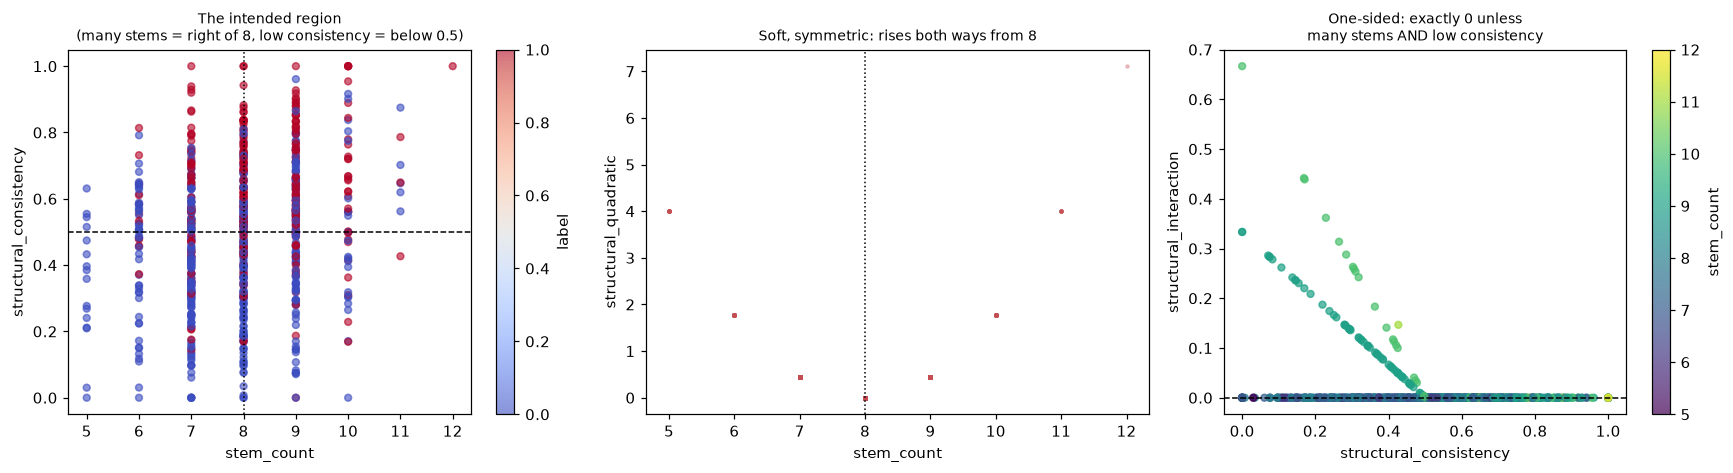

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sc = axes[0].scatter(df["stem_count"], df["structural_consistency"],
                     c=df["label"], cmap="coolwarm", alpha=0.6, s=20)
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].axvline(8.0, color="k", ls=":", lw=1)
axes[0].set_xlabel("stem_count")
axes[0].set_ylabel("structural_consistency")
axes[0].set_title("The intended region\n(many stems = right of 8, low consistency = below 0.5)",
                  fontsize=9)
plt.colorbar(sc, ax=axes[0], label="label")

axes[1].plot(df["stem_count"], df["quadratic"], "o", ms=2, alpha=0.3, color="#C44E52")
axes[1].axvline(8.0, color="k", ls=":", lw=1)
axes[1].set_xlabel("stem_count")
axes[1].set_ylabel("structural_quadratic")
axes[1].set_title("Soft, symmetric: rises both ways from 8", fontsize=9)

im = axes[2].scatter(df["structural_consistency"], df["interaction"],
                     c=df["stem_count"], cmap="viridis", s=20, alpha=0.7)
axes[2].axhline(0.0, color="k", ls="--", lw=1)
axes[2].set_xlabel("structural_consistency")
axes[2].set_ylabel("structural_interaction")
axes[2].set_title("One-sided: exactly 0 unless\nmany stems AND low consistency", fontsize=9)
plt.colorbar(im, ax=axes[2], label="stem_count")
plt.show()

In [12]:
print("plausible rate by structural region, all 800 rows:\n")
region = pd.DataFrame(m2["structural_region"]).T
region["n"] = region["n"].astype(int)
print(region.to_string())

plausible rate by structural region, all 800 rows:

                                     n  plausible_rate
few stems + adequate consistency   259        0.505792
few stems + low consistency        289        0.231834
many stems + adequate consistency  162        0.617284
many stems + low consistency        90        0.277778


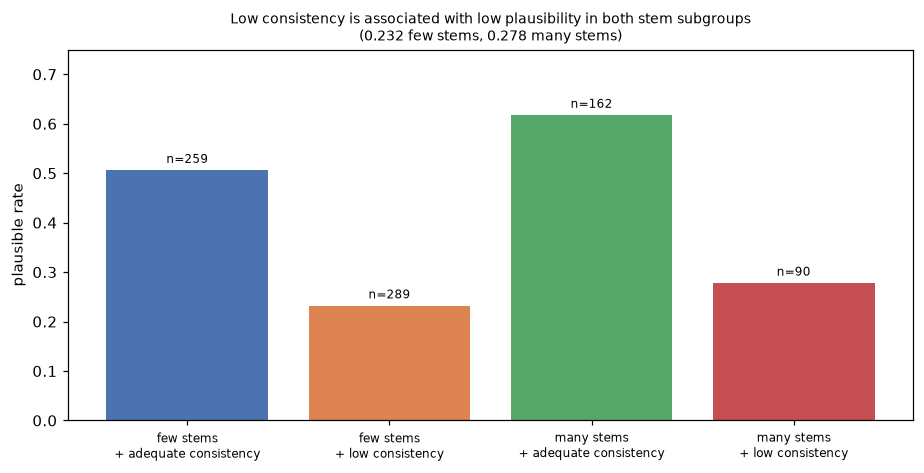

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
keys = list(region.index)
vals = [region.loc[k, "plausible_rate"] for k in keys]
ns = [region.loc[k, "n"] for k in keys]
ax.bar(range(len(keys)), vals, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
for i, (v, n) in enumerate(zip(vals, ns)):
    ax.text(i, v + 0.015, f"n={n}", ha="center", fontsize=8)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels([k.replace(" + ", "\n+ ") for k in keys], fontsize=8)
ax.set_ylabel("plausible rate")
ax.set_ylim(0, 0.75)
ax.set_title("Low consistency is associated with low plausibility in both stem subgroups\n"
             "(0.232 few stems, 0.278 many stems)", fontsize=9)
plt.show()

### The prior does target the intended region

- **`structural_quadratic`** is nonzero on 67% of rows, bounded (max 7.11), and rises in both
  directions from `stem_count = 8` — genuinely soft, with no threshold anywhere.
- **`structural_interaction`** is **exactly zero on 89% of rows** and bounded (max 0.667). It fires
  only where intended: many stems *and* consistency below 0.5. The sparsity is the point — it is a
  targeted penalty, not a global reshaping of the feature space.
- **The observed data confirm a strong conditional pattern in the intended region.** Plausible
  rates by region:

| region | n | plausible rate |
|---|---|---|
| few stems + adequate consistency | 259 | 0.506 |
| few stems + low consistency | 289 | 0.232 |
| many stems + adequate consistency | 162 | **0.617** |
| many stems + low consistency | 90 | **0.278** |

Within the many-stem subgroup, lowering structural consistency changes the plausible rate from
**0.617 to 0.278, a drop of 0.339** — a strong conditional pattern, and the one the prior's
interaction term encodes.

An important qualification, since it bears on how much the interaction can add: low consistency is
associated with low plausibility in the *few-stems* subgroup too, where the rate is **0.232** —
in fact slightly lower than the many-stems group. So low consistency has a broad association with
implausibility across both stem subgroups, and the 90-row many-stems cell is not the worst region in
the data. The engineered prior isolates that particular cell, which is a narrow target.

Its correlation with the label is −0.089, modestly negative as intended. The quadratic's is −0.076.
Both are weak, which is the honest reading: the prior columns carry a little signal, not much.

## 5. The prior works, the effect is small — why

A prior that demonstrably targets a real and strong region of the data (Section 4) produces only
+0.0024 AUROC. That gap deserves an explanation rather than a shrug, and two mechanisms are
identifiable from what has already been measured in this project.

**1. The signal is largely already available to the linear model.** Task 3 found
`structural_consistency` was the single strongest logistic coefficient (+0.597) and `stem_count` was
+0.222. The prior's interaction is essentially "many stems *combined with* low consistency", and
`structural_consistency` alone already carries most of that. Adding a column that re-encodes an
existing linear combination of two features the model can already see can only add the residual
nonlinearity — which on this dataset is small. This is consistent with the Task 3 nonlinear
baseline's finding that generic nonlinearity (HGB, AUROC 0.8054) does *worse* than a linear model
here.

**2. Low consistency is already broadly associated with low plausibility.** As Section 4 shows, the
few-stems subgroup has a plausible rate of 0.232 when consistency is low — lower than the many-stems
group's 0.278. Low `structural_consistency` therefore has a broad association with low plausibility
across both stem subgroups, and the baseline already observes that feature directly. By contrast the
explicit many-stems × low-consistency interaction applies to only the smaller 90-row subset. The
engineered interaction therefore adds only **residual** information beyond a feature the baseline
already sees.

**These are interpretations, not tested mechanisms.** Neither claim was isolated experimentally in
this task; both are readings of measurements from Task 3 and from Section 4 above. Establishing them
would need an ablation that removes `structural_consistency` from the baseline, which is outside
the scope of this task and would change the reference conditions.

## 6. Summary

### What worked as designed

- **Identical folds** (`9b587aa3d19a36f7`), asserted in code; scaling refit per training fold for every condition.
- **The prior is genuinely soft and transparent** — a squared deviation, not a threshold, and a one-sided product that is exactly zero on 89% of rows. No hard rule anywhere.
- **The engineered prior explicitly targets the intended region** (a one-sided many-stems × low-consistency product that is exactly zero on 89% of rows), and the observed data confirm a strong conditional pattern there: within the many-stem subgroup, lowering consistency moves the plausible rate from 0.617 to 0.278, a drop of 0.339.
- **The generic control did its job.** It is comparable in mathematical form, chosen without labels, and it separates a domain-informed interaction (+0.0022 vs LR2c, +0.0055 vs P2c) from any extra nonlinearity. This is the strongest positive finding in the task.
- **Nothing was tuned to win.** Constants came from the public design description, fixed before fitting; P2 was declared the main condition in advance and was not swapped for the better-scoring P2d.
- **Confusion matrices reconcile** for all 40 fold/condition combinations.

### Negative and unexpected findings

1. **The absolute effect is small and not demonstrable.** LR2 − LR0 AUROC **+0.0024** with signs on both sides of zero (3/5 folds). P2 − P0 AUROC **+0.0005**. Neither clears noise on the headline metric.

2. **Accuracy and F1 are more convincing than AUROC.** P2 improves accuracy (+0.0088) and F1 (+0.0106) in **5 of 5 folds**, and LR2 improves F1 (+0.0047) in 3/5. So the prior does something repeatable, just not much, and Brier gets marginally worse for P2 (+0.0015).

3. **Beating HGB0 is not the win it looks like.** LR2 − HGB0 = +0.0260, but HGB0 was already 0.024 behind LR0 (Task 3). The prior added ~0.002 to a strong baseline; it did not rescue a weak one.

4. **A stronger diagnostic, the intended region is real and strong, yet the prior barely moves the model.** Plausible rate drops 0.617 → 0.278 when consistency is low in the many-stems region — the largest structural effect in the data — and encoding it yields +0.0024 AUROC. A weak effect from a real target is a more interesting result than a strong effect from an arbitrary one.

5. **The generic control *hurt* the prototype model.** P2c − P0 = **−0.0050** AUROC, worse in 4/5 folds, versus P2's +0.0005. So blind nonlinear columns are not neutral in this model family; the gain for P2 is the difference between a mildly helpful and a mildly harmful addition.

6. **The alternative encoding behaved best and was not promoted.** P2d (bounded penalty inside the distance) is the only condition with positive AUROC in 5/5 folds (+0.0027) and a Brier score that improves. Declining to promote it after seeing its score is the right call, but it is worth recording that distance-based encoding may suit soft priors better than extra columns.

### Implications for later modelling

- **M2 should be reported as "small positive effect, larger than the chosen generic control, but not consistently positive across folds on AUROC."** That wording is what the fold results support. No significance test was performed anywhere in this task, and none should be implied.
- **The generic-control result is scoped to this experiment.** In this experiment, the domain-informed nonlinear feature performed better than the chosen complexity-matched label-blind nonlinear control in both model families (LR2 − LR2c = +0.0022, P2 − P2c = +0.0055 AUROC). The methodological lesson is separate and narrower: *this illustrates the value of including a complexity-matched non-domain control when evaluating knowledge-informed features.* Without the control, a small gain could not have been attributed to the prior rather than to an extra nonlinear column.
- **Task 7 raises a caution for M3.** If module aggregation mainly re-encodes information already available through strong individual proxies, predictive gains may be small. **Task 8 should test this rather than assume it.**
- **M3 should initially be compared to its own corresponding raw-feature baseline and its own incorrect-grouping control**, not required to beat LR2. Requiring a network prior to outperform the best logistic model found anywhere in the project would set a bar that no prior-informed condition can be expected to clear, and would not test anything specific to the network prior. The informative comparisons are M3 against raw features, and correctly-grouped against incorrectly-grouped aggregation.
- **Do not let a small effect get promoted by choosing among encodings.** The P2d decision shows how easily that happens: a variant scoring +0.0027 AUROC in 5/5 folds was declined because the main condition had been declared in advance.

**No data was regenerated. Latent truth was not used anywhere in this notebook. No network/module prior, relevance weighting, or rejection was implemented.**